In [1]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import rasterio

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [2]:
# =========================
# PATHS
# =========================

train_path = "EuroSAT_Dataset\\EuroSATallBands\\train"
val_path   = "EuroSAT_Dataset\\EuroSATallBands\\val"
test_path  = "EuroSAT_Dataset\\EuroSAT_test_flat"

# =========================
# HYPERPARAMETERS
# =========================

NUM_CLASSES = 10

BATCH_SIZE = 32
EPOCHS = 30

LR = 1e-4
WEIGHT_DECAY = 1e-4

IMAGE_SIZE = 64

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

In [4]:
class EuroSAT13BandDataset(Dataset):

    def __init__(self, root_dir):

        self.root_dir = root_dir

        self.classes = sorted(
            [
                d for d in os.listdir(root_dir)
                if os.path.isdir(os.path.join(root_dir, d))
            ]
        )

        self.class_to_idx = {
            cls_name: idx
            for idx, cls_name in enumerate(self.classes)
        }

        self.samples = []

        for cls in self.classes:

            cls_dir = os.path.join(root_dir, cls)

            for file in os.listdir(cls_dir):

                if file.endswith(".tif"):

                    self.samples.append(
                        (
                            os.path.join(cls_dir, file),
                            self.class_to_idx[cls]
                        )
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        path, label = self.samples[idx]

        with rasterio.open(path) as src:
            image = src.read().astype(np.float32)

        image = np.nan_to_num(image)

        # shape:
        # (13,64,64)

        mean = image.mean(axis=(1,2), keepdims=True)
        std = image.std(axis=(1,2), keepdims=True)

        image = (image - mean) / (std + 1e-6)

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return image, label

In [5]:
train_dataset = EuroSAT13BandDataset(train_path)
val_dataset   = EuroSAT13BandDataset(val_path)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))

print("Classes:")
print(train_dataset.classes)

Train: 18900
Val: 4050
Classes:
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [7]:
model = models.densenet121(
    weights=None
)

# Replace first layer

model.features.conv0 = nn.Conv2d(
    in_channels=13,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

num_features = model.classifier.in_features

model.classifier = nn.Linear(
    num_features,
    NUM_CLASSES
)

model = model.to(device)

print(model)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(13, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=

In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.5
)

In [9]:
class EarlyStopping:

    def __init__(
        self,
        patience=7,
        min_delta=0
    ):

        self.patience = patience
        self.min_delta = min_delta

        self.best_loss = None
        self.counter = 0

        self.stop = False

    def __call__(self, val_loss):

        if self.best_loss is None:

            self.best_loss = val_loss

        elif val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss
            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:
                self.stop = True


early_stopping = EarlyStopping(
    patience=7
)

In [10]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_val_acc = 0

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    # ====================
    # TRAIN
    # ====================

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    train_bar = tqdm(
        train_loader,
        desc="Training"
    )

    for images, labels in train_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, preds = outputs.max(1)

        total += labels.size(0)

        correct += preds.eq(labels).sum().item()

        train_bar.set_postfix(
            loss=loss.item(),
            acc=100*correct/total
        )

    train_loss = (
        running_loss /
        len(train_loader)
    )

    train_acc = (
        100 * correct / total
    )

    # ====================
    # VALIDATION
    # ====================

    model.eval()

    running_loss = 0

    correct = 0
    total = 0

    with torch.no_grad():

        val_bar = tqdm(
            val_loader,
            desc="Validation"
        )

        for images, labels in val_bar:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += loss.item()

            _, preds = outputs.max(1)

            total += labels.size(0)

            correct += preds.eq(
                labels
            ).sum().item()

    val_loss = (
        running_loss /
        len(val_loader)
    )

    val_acc = (
        100 * correct / total
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}%"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_densenet121_13band.pth"
        )

        print("Best model saved")

    early_stopping(val_loss)

    if early_stopping.stop:

        print("\nEarly stopping triggered.")
        break


Epoch [1/30]


Training:   0%|          | 0/591 [00:00<?, ?it/s]

Validation:   0%|          | 0/127 [00:00<?, ?it/s]

Train Loss: 0.9043 | Train Acc: 70.05%
Val Loss: 0.4545 | Val Acc: 84.62%
Best model saved

Epoch [2/30]


Training:   0%|          | 0/591 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/127 [00:00<?, ?it/s]

Train Loss: 0.0038 | Train Acc: 99.91%
Val Loss: 0.2336 | Val Acc: 93.43%

Epoch [24/30]


Training:   0%|          | 0/591 [00:00<?, ?it/s]

Validation:   0%|          | 0/127 [00:00<?, ?it/s]

Train Loss: 0.0043 | Train Acc: 99.90%
Val Loss: 0.2119 | Val Acc: 94.30%

Early stopping triggered.


### Cell 11: Curves


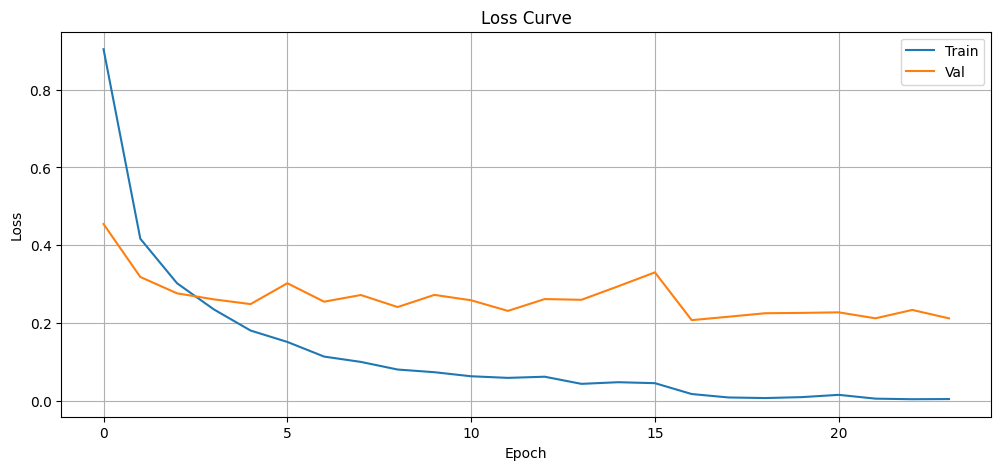

In [11]:
plt.figure(figsize=(12,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Val")

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

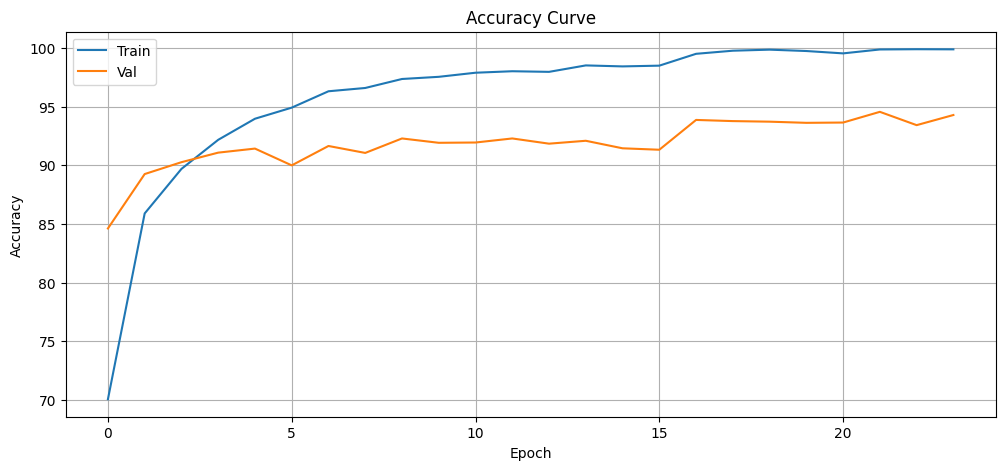

In [12]:
plt.figure(figsize=(12,5))

plt.plot(train_accs,label="Train")
plt.plot(val_accs,label="Val")

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()

### Cell 12

In [13]:
model.load_state_dict(
    torch.load(
        "best_densenet121_13band.pth",
        map_location=device
    )
)

model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(13, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=

In [14]:
y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in tqdm(val_loader):

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(1)

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

  0%|          | 0/127 [00:00<?, ?it/s]

In [15]:
acc = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9457
Precision: 0.9461
Recall   : 0.9457
F1 Score : 0.9455


In [16]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_dataset.classes
    )
)

                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.94      0.95       450
              Forest       0.98      0.99      0.99       450
HerbaceousVegetation       0.88      0.91      0.90       450
             Highway       0.96      0.87      0.91       375
          Industrial       0.92      0.98      0.95       375
             Pasture       0.94      0.92      0.93       300
       PermanentCrop       0.88      0.87      0.87       375
         Residential       0.97      0.98      0.97       450
               River       0.98      0.97      0.97       375
             SeaLake       0.98      1.00      0.99       450

            accuracy                           0.95      4050
           macro avg       0.95      0.94      0.94      4050
        weighted avg       0.95      0.95      0.95      4050



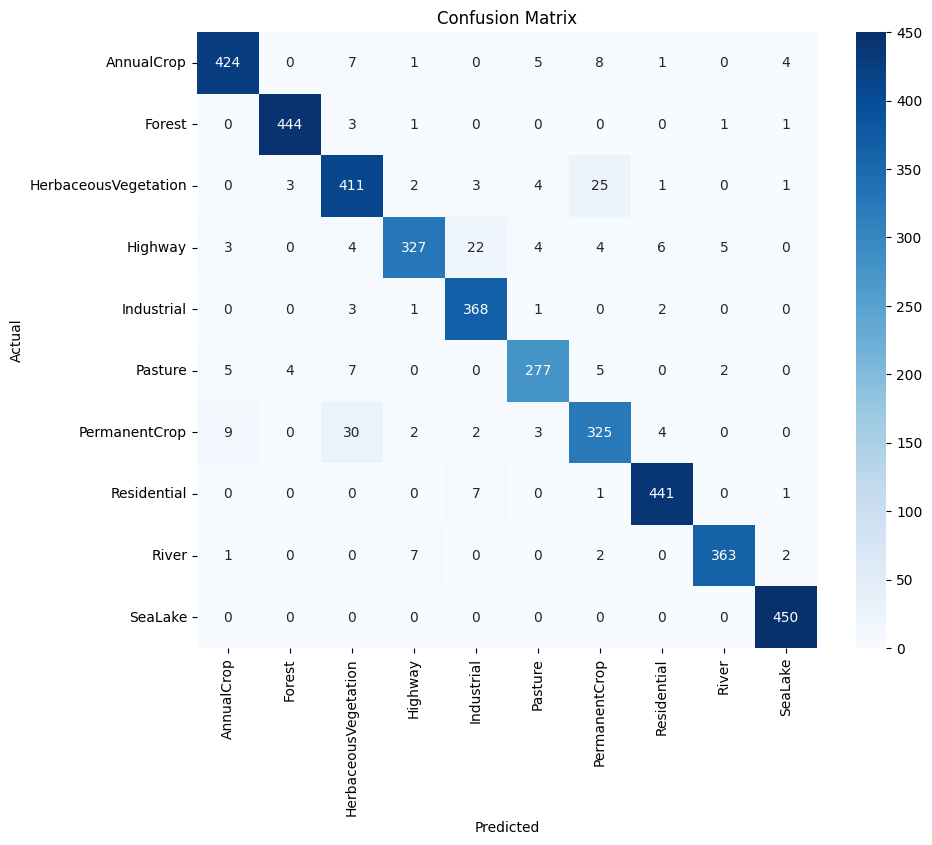

In [17]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()